In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [31]:
df_station = pd.read_csv("../../../data/clean/Yashaswi/AQI_station.csv")

# Ensure column name consistency
df_station.rename(columns={"NAPS ID": "NAPS_ID"}, inplace=True)


In [32]:
df_station.columns

Index(['NAPS_ID', 'City', 'Province/Territory', 'Latitude', 'Longitude'], dtype='str')

In [34]:
df_station["Province/Territory"].value_counts()

Province/Territory
BC    25
QC    12
AB    12
ON     8
NL     4
NB     3
NS     2
MB     2
SK     2
YU     1
NT     1
Name: count, dtype: int64

In [26]:
df_station["Province"].unique()

<StringArray>
['NL', 'NS', 'NB', 'QC', 'ON', 'MB', 'SK', 'AB', 'BC', 'YU', 'NT']
Length: 11, dtype: str

In [42]:
df_station.loc[df_station["Province"] == "NS", "NAPS_ID"].unique()

array([30118, 30310])

## AQI → colour function (EPA standard)

In [35]:
def aqi_to_color(aqi):
    if pd.isna(aqi): return "gray"
    if aqi <= 50: return "green"
    elif aqi <= 100: return "yellow"
    elif aqi <= 150: return "orange"
    elif aqi <= 200: return "red"
    elif aqi <= 300: return "purple"
    else: return "maroon"


## Legend (reuse everywhere)

In [36]:
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Good (0–50)', markerfacecolor='green', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Moderate (51–100)', markerfacecolor='yellow', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='USG (101–150)', markerfacecolor='orange', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Unhealthy (151–200)', markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Very Unhealthy (201–300)', markerfacecolor='purple', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Hazardous (301+)', markerfacecolor='maroon', markersize=8),
]

## Load dataset
- Define pollutant AQI files

In [37]:

DATA_DIR = Path("../../../data/raw/Yashaswi/AQI/AllPollutantsHourly/")

pollutant_files = {
    "PM2.5": "AQI_PM2.5_2010_2024.csv",
    "PM10":  "AQI_PM10_2010_2024.csv",
    "O3":    "AQI_O3_2010_2024.csv",
    "NO2":   "AQI_NO2_2010_2024.csv",
    "SO2":   "AQI_SO2_2010_2024.csv",
    "CO":    "AQI_CO_2010_2024.csv",
}

## Loop over ALL pollutants and plot station maps

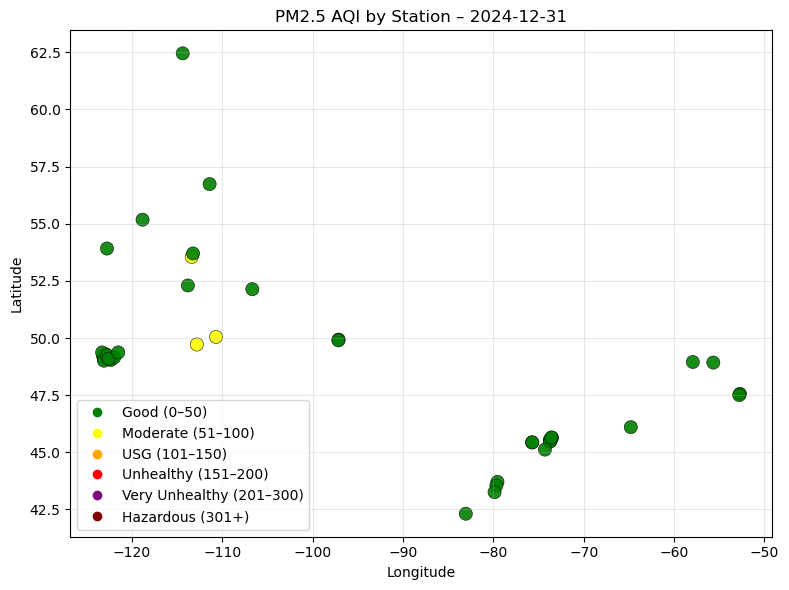

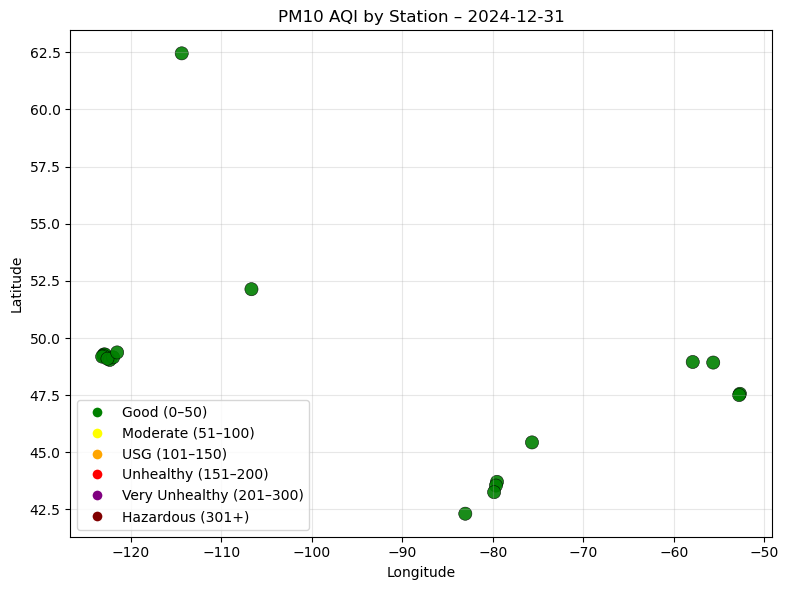

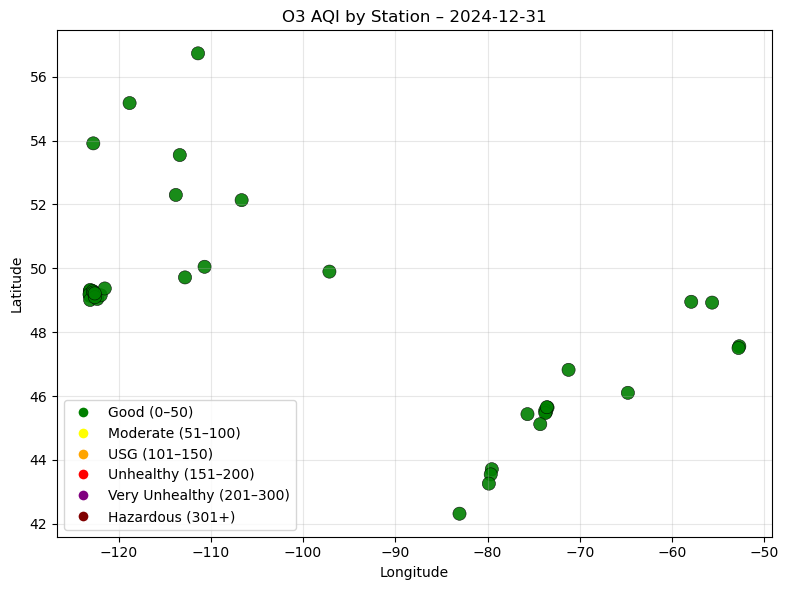

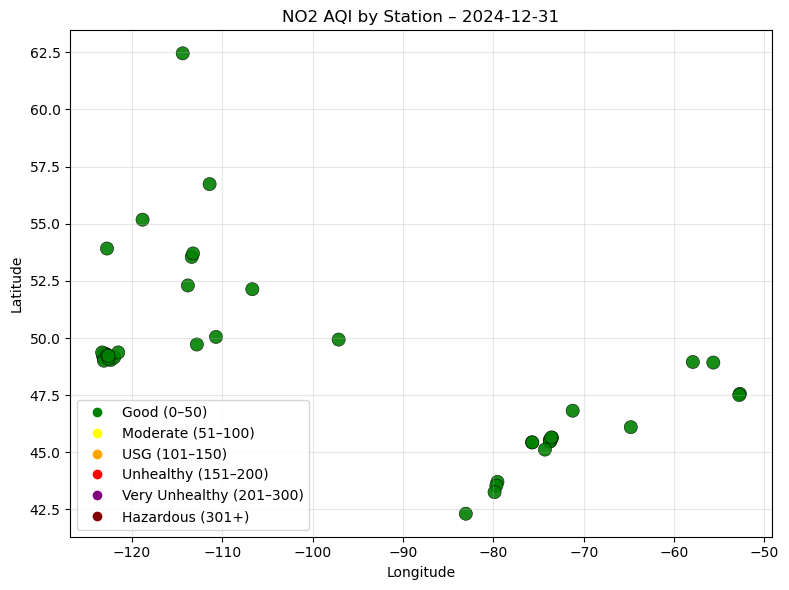

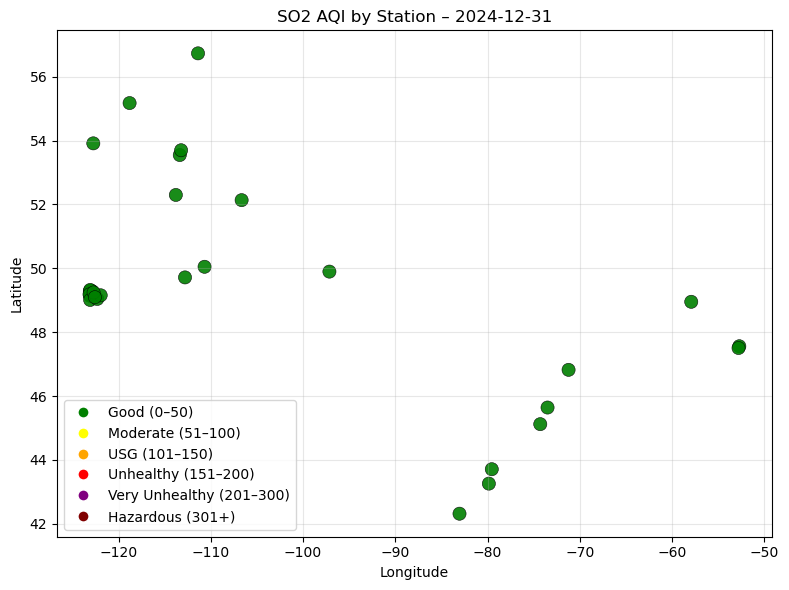

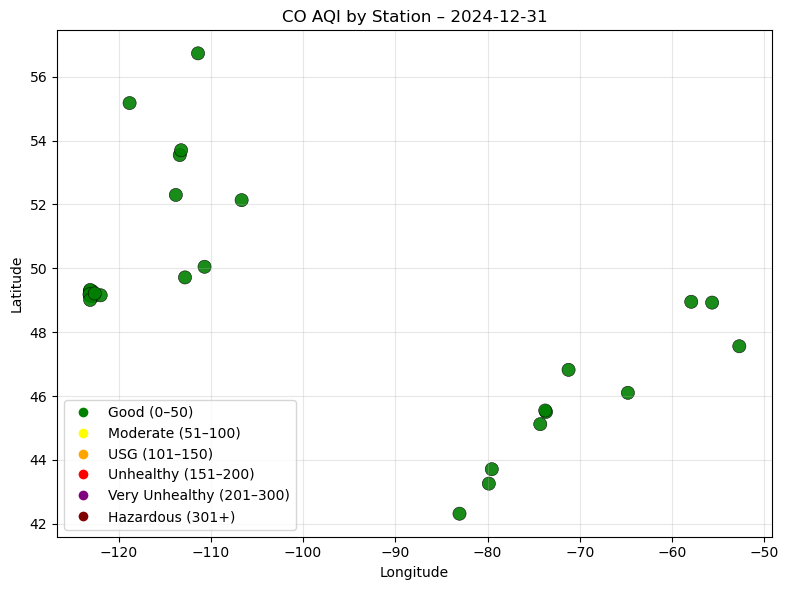

In [38]:
for pollutant, fname in pollutant_files.items():

    # Read pollutant AQI data
    df_aqi = pd.read_csv(DATA_DIR / fname)
    df_aqi.rename(columns={"NAPS ID": "NAPS_ID"}, inplace=True)
    df_aqi["Date"] = pd.to_datetime(df_aqi["Date"])

    # Choose date (latest available for that pollutant)
    plot_date = df_aqi["Date"].max()
    df_day = df_aqi[df_aqi["Date"] == plot_date].copy()

    # Merge with station locations
    map_df = df_day.merge(
        df_station,
        on="NAPS_ID",
        how="left"
    )

    # AQI colour coding
    map_df["AQI_Color"] = map_df["AQI"].apply(aqi_to_color)

    # Plot
    plt.figure(figsize=(8, 6))

    plt.scatter(
        map_df["Longitude"],
        map_df["Latitude"],
        c=map_df["AQI_Color"],
        s=90,
        edgecolors="black",
        linewidths=0.4,
        alpha=0.9
    )

    plt.title(f"{pollutant} AQI by Station – {plot_date.date()}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend(handles=legend_elements, loc="lower left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [39]:

df_station.rename(columns={"NAPS ID": "NAPS_ID",
                           "Province/Territory": "Province"},
                  inplace=True)


## Province AQI map for ALL pollutants

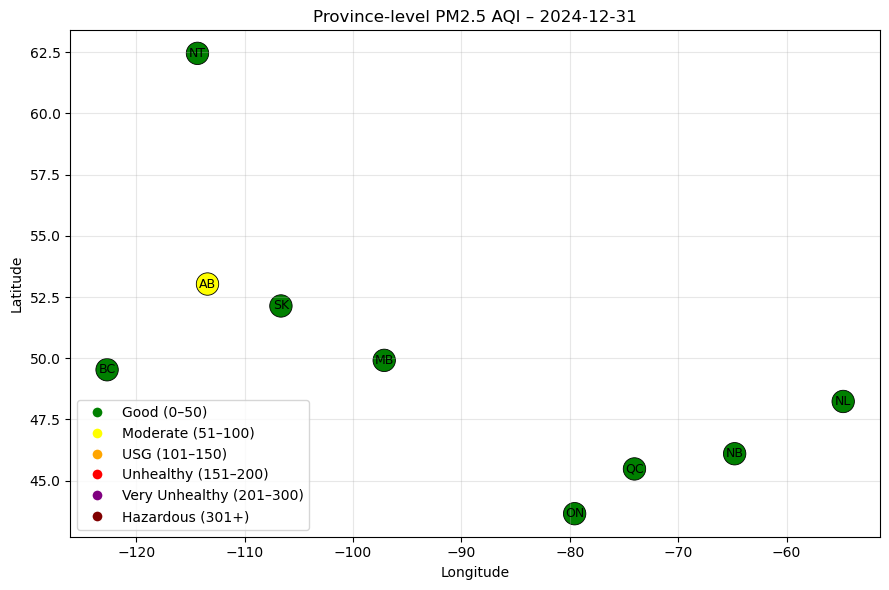

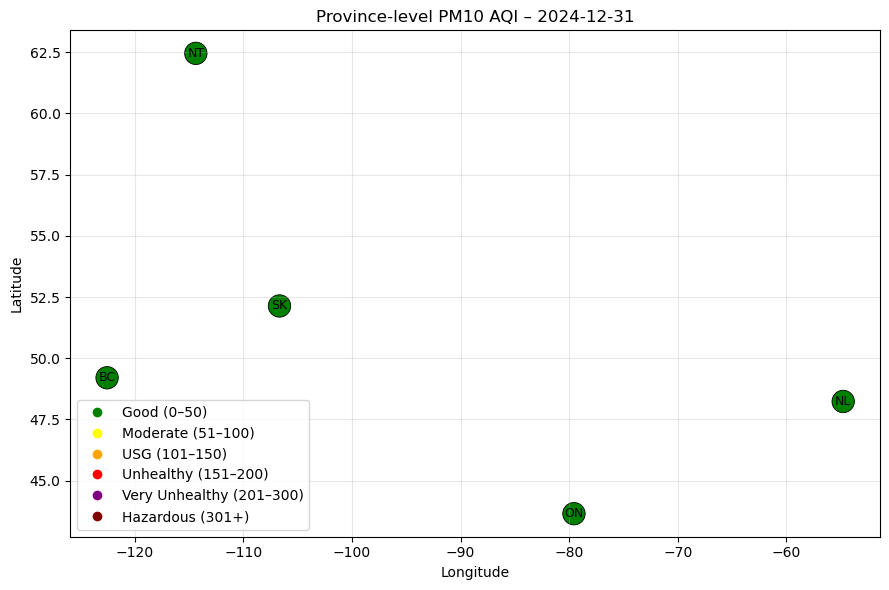

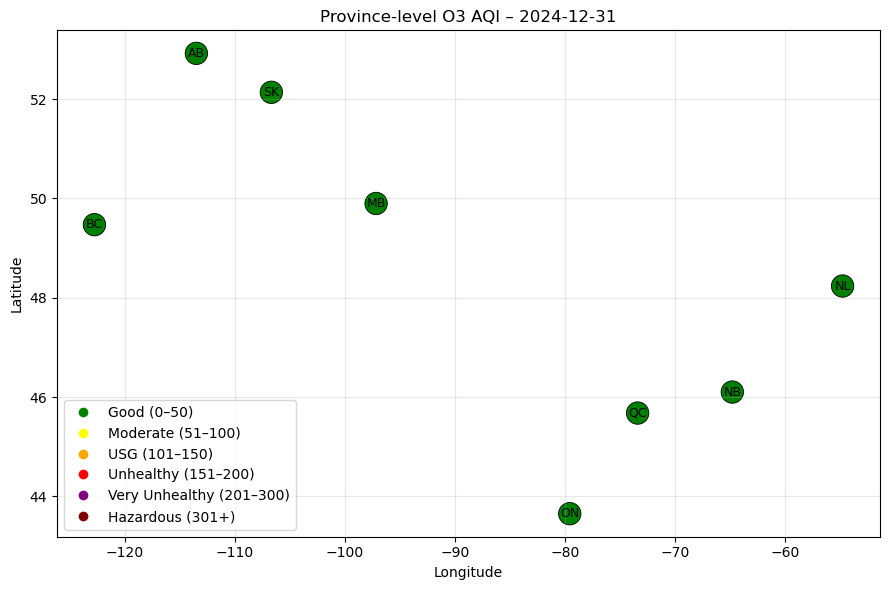

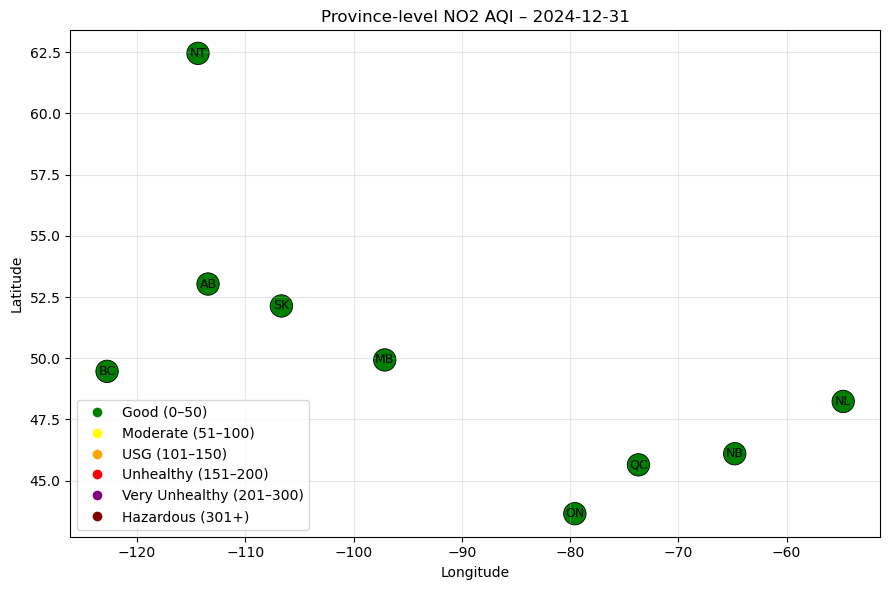

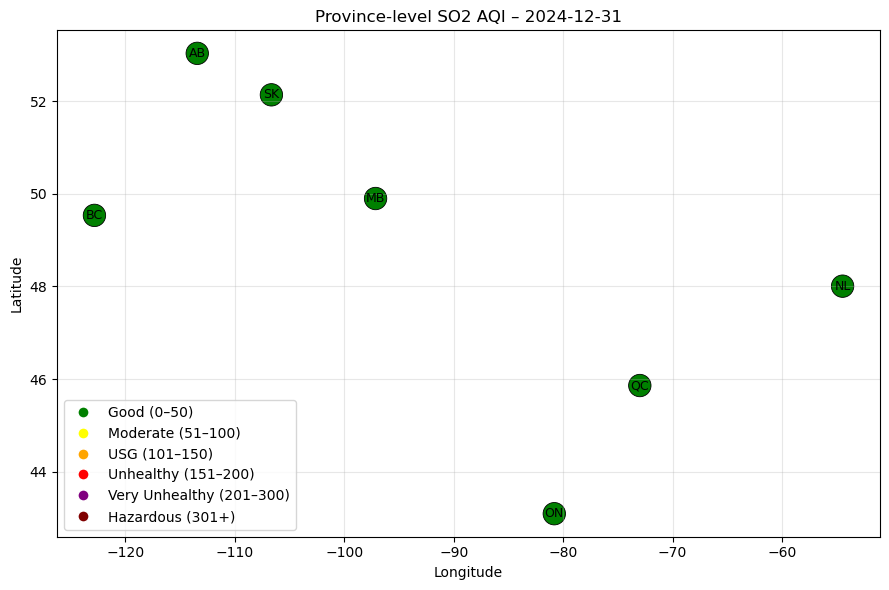

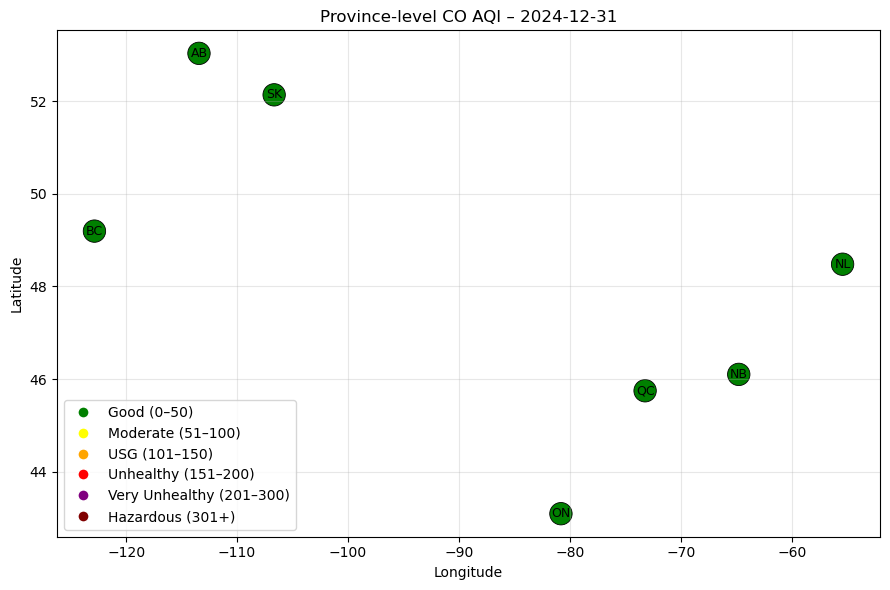

In [40]:
for pollutant, filename in pollutant_files.items():

    # 1️⃣ Read pollutant AQI data
    df_aqi = pd.read_csv(DATA_DIR / filename)
    df_aqi.rename(columns={"NAPS ID": "NAPS_ID"}, inplace=True)
    df_aqi["Date"] = pd.to_datetime(df_aqi["Date"])

    # 2️⃣ Pick date (latest available for that pollutant)
    plot_date = df_aqi["Date"].max()
    df_day = df_aqi[df_aqi["Date"] == plot_date]

    # 3️⃣ Merge with station metadata
    df_merge = df_day.merge(
        df_station,
        on="NAPS_ID",
        how="left"
    )

    # 4️⃣ Aggregate to province level (EPA worst‑case logic)
    province_aqi = (
        df_merge
        .groupby("Province", as_index=False)
        .agg({
            "AQI": "max",
            "Latitude": "mean",
            "Longitude": "mean"
        })
    )

    province_aqi["AQI_Color"] = province_aqi["AQI"].apply(aqi_to_color)

    # 5️⃣ Plot province map
    plt.figure(figsize=(9, 6))

    plt.scatter(
        province_aqi["Longitude"],
        province_aqi["Latitude"],
        c=province_aqi["AQI_Color"],
        s=260,
        edgecolors="black",
        linewidths=0.6
    )

    # Province labels
    for _, row in province_aqi.iterrows():
        plt.text(
            row["Longitude"],
            row["Latitude"],
            row["Province"],
            fontsize=9,
            ha="center",
            va="center"
        )

    plt.title(f"Province‑level {pollutant} AQI – {plot_date.date()}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend(handles=legend_elements, loc="lower left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [41]:
set(df_station["Province"])

{'AB', 'BC', 'MB', 'NB', 'NL', 'NS', 'NT', 'ON', 'QC', 'SK', 'YU'}

In [28]:
set(df_merge["Province"])

{'AB', 'BC', 'NB', 'NL', 'ON', 'QC', 'SK', nan}

## station_daily_aqi
NAPS_ID | Date | AQI | Dominant_Pollutant

## AQI colors

In [45]:
def aqi_to_color(aqi):
    if pd.isna(aqi): return "lightgray"
    if aqi <= 50: return "green"
    elif aqi <= 100: return "yellow"
    elif aqi <= 150: return "orange"
    elif aqi <= 200: return "red"
    elif aqi <= 300: return "purple"
    else: return "maroon"

## Step 1 — Loop over pollutants and prepare province‑level monthly AQI

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

DATA_DIR = Path("../../../data/raw/Yashaswi/AQI/AllPollutantsHourly")

for pollutant, fname in pollutant_files.items():

    # 1️⃣ Read pollutant AQI file
    df = pd.read_csv(DATA_DIR / fname)
    df.rename(columns={"NAPS ID": "NAPS_ID"}, inplace=True)
    df["Date"] = pd.to_datetime(df["Date"])

    # 2️⃣ Merge with province info
    df = df.merge(
        df_station[["NAPS_ID", "Province"]],
        on="NAPS_ID",
        how="left"
    )

    # 3️⃣ Convert to monthly period
    df["Month"] = df["Date"].dt.to_period("M").dt.to_timestamp()

    # 4️⃣ Province‑level monthly mean AQI
    province_monthly = (
        df
        .groupby(["Province", "Month"], as_index=False)
        .agg(mean_AQI=("AQI", "mean"))
    )

## Line chart (AQI by province, color coded)

C:\Users\biauser\AppData\Local\Temp\ipykernel_11328\3209191064.py:22: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


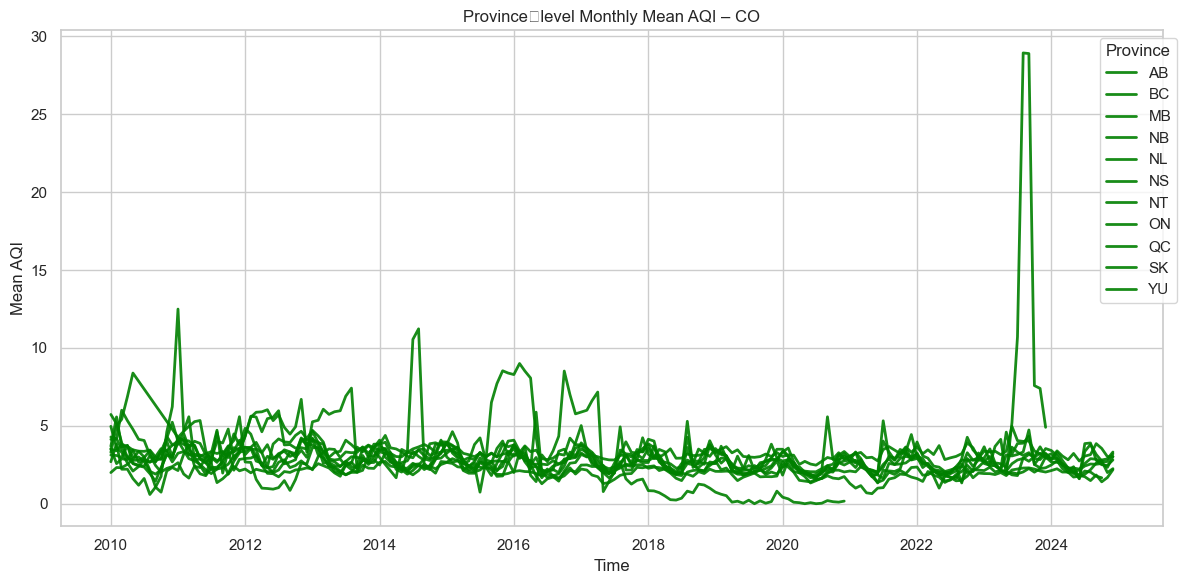

In [50]:
    plt.figure(figsize=(12, 6))

    for prov in province_monthly["Province"].dropna().unique():
        sub = province_monthly[province_monthly["Province"] == prov]

        # Color by overall AQI severity for that province
        color = aqi_to_color(sub["mean_AQI"].mean())

        plt.plot(
            sub["Month"],
            sub["mean_AQI"],
            label=prov,
            color=color,
            linewidth=2,
            alpha=0.9
        )

    plt.title(f"Province‑level Monthly Mean AQI – {pollutant}")
    plt.xlabel("Time")
    plt.ylabel("Mean AQI")
    plt.legend(title="Province", bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    plt.show()

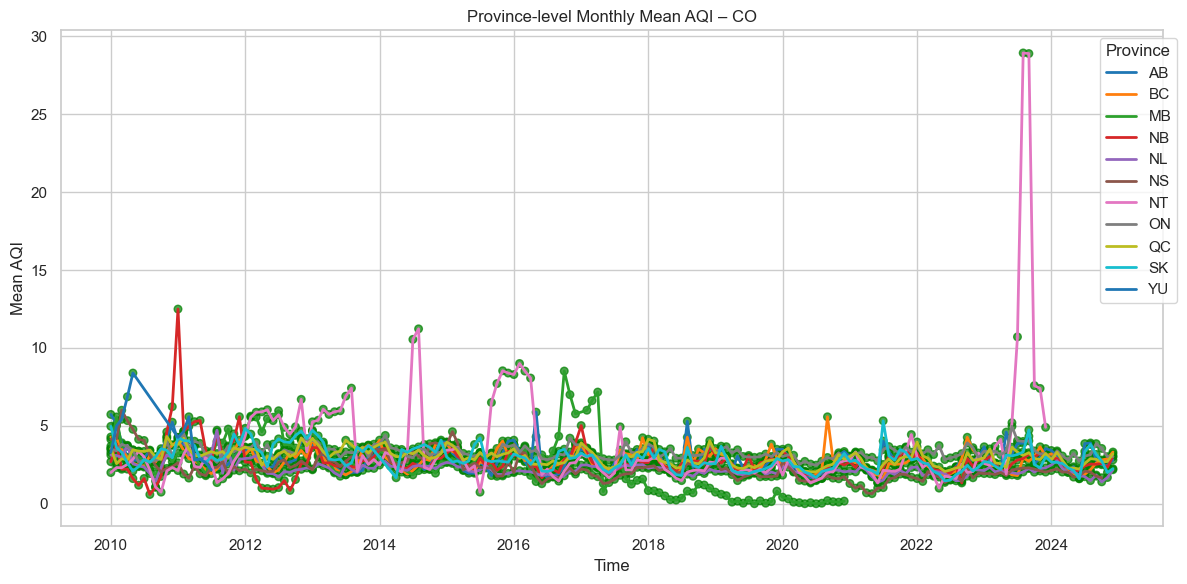

In [51]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=province_monthly,
    x="Month",
    y="mean_AQI",
    hue="Province",
    palette="tab10",
    linewidth=2
)

# overlay AQI category markers
plt.scatter(
    province_monthly["Month"],
    province_monthly["mean_AQI"],
    c=province_monthly["mean_AQI"].apply(aqi_to_color),
    s=30,
    alpha=0.7
)

plt.title(f"Province-level Monthly Mean AQI – {pollutant}")
plt.xlabel("Time")
plt.ylabel("Mean AQI")
plt.legend(title="Province", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## one plot per pollutant

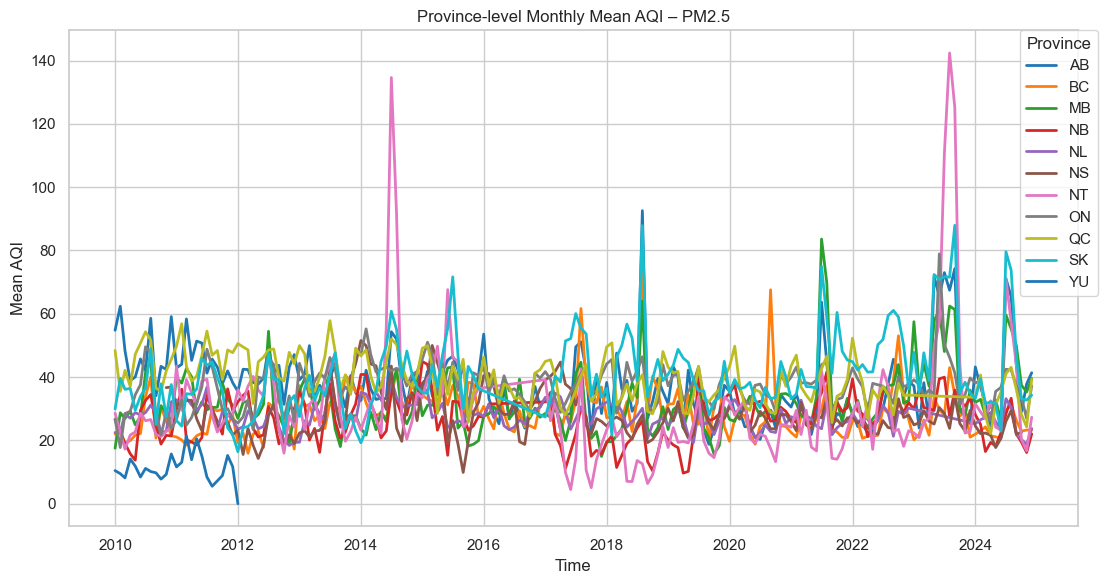

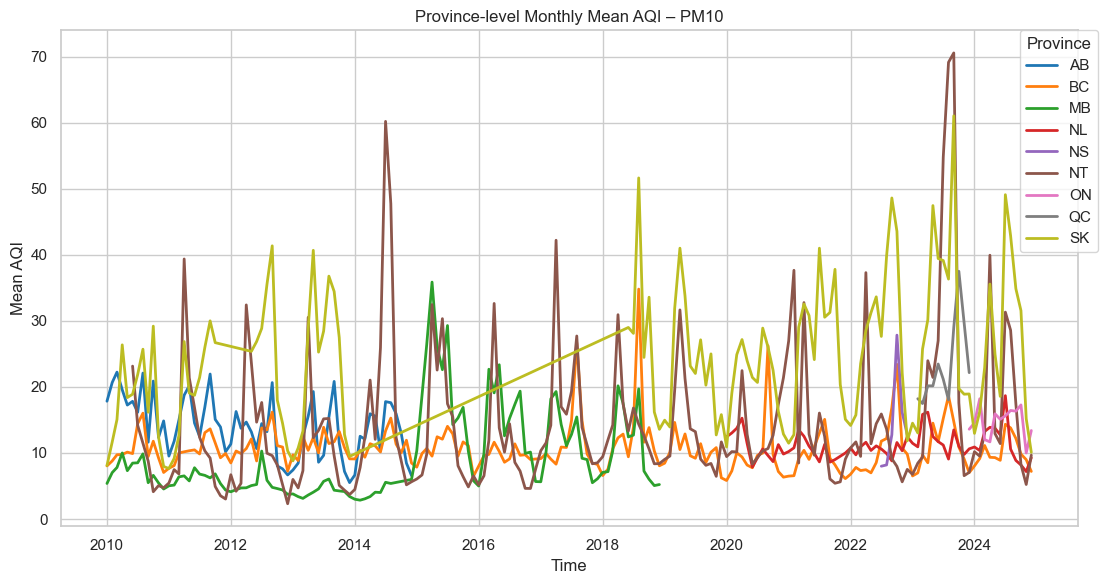

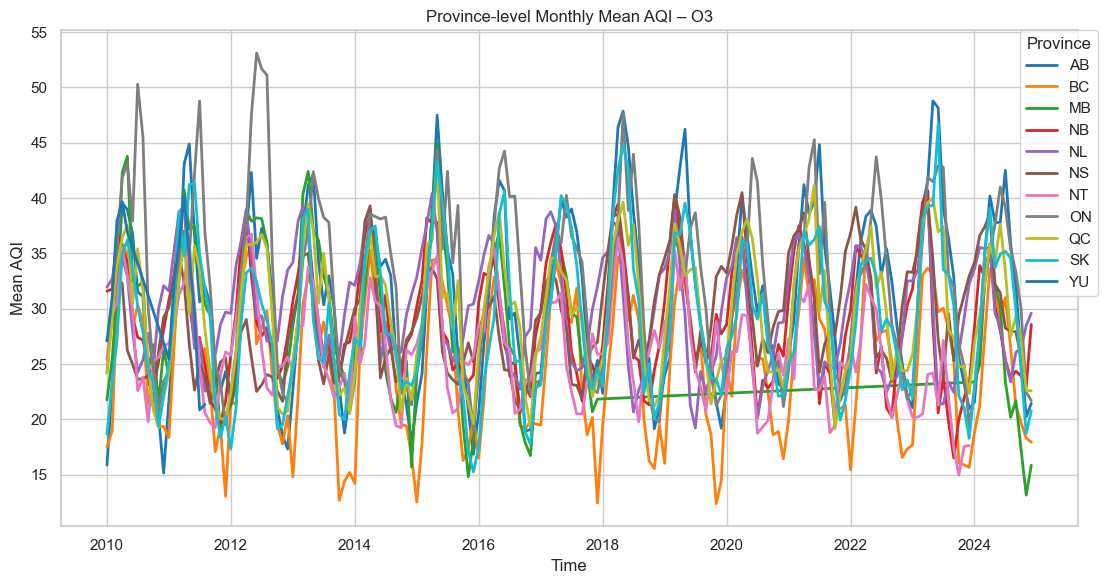

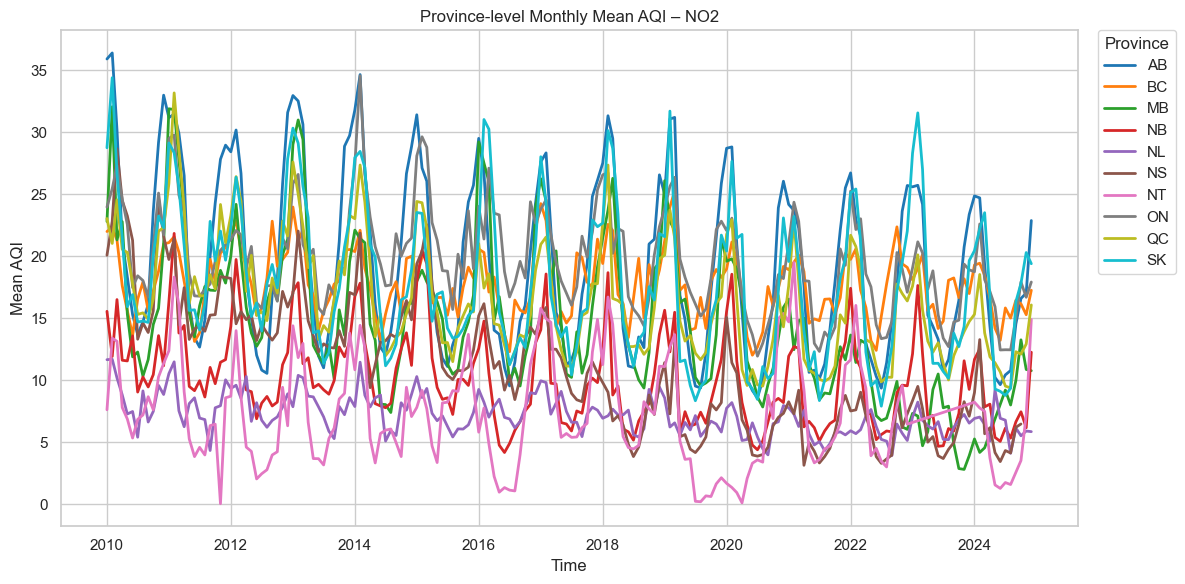

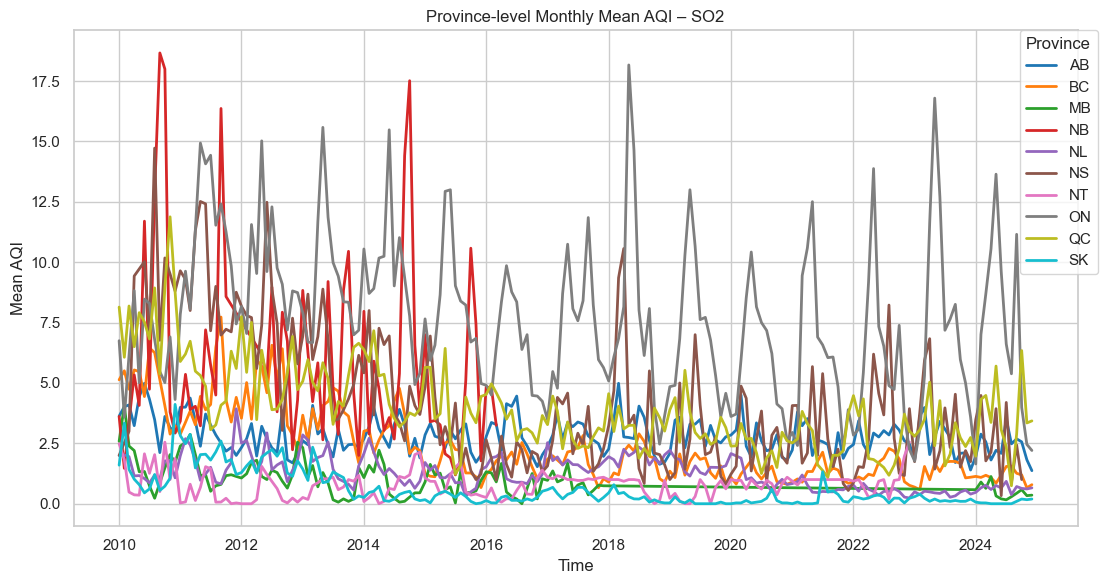

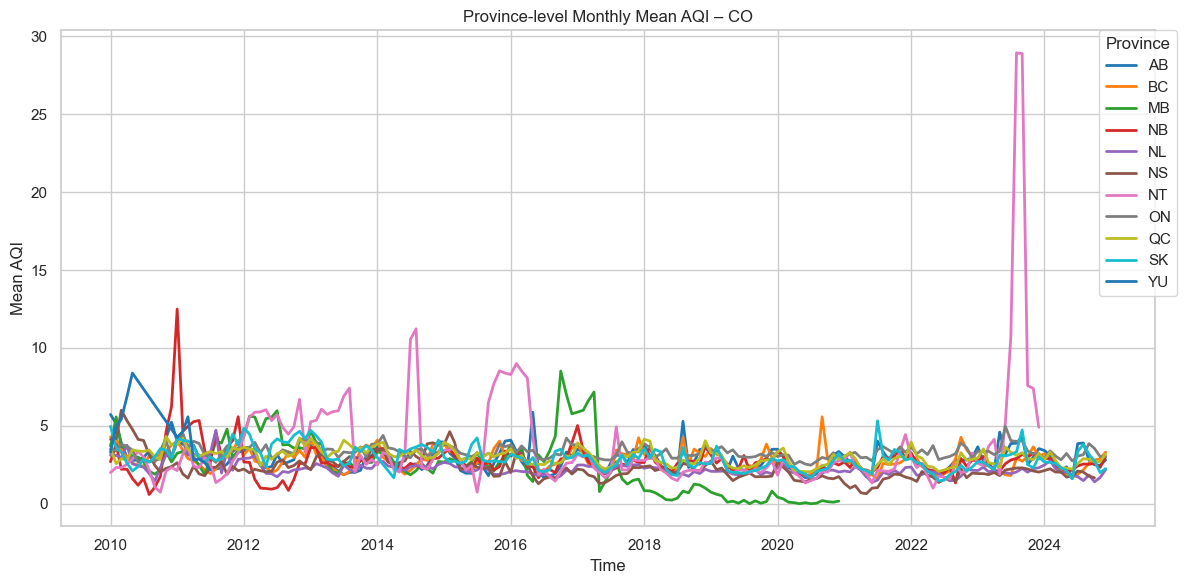

In [52]:
for pollutant, fname in pollutant_files.items():

    # 1️⃣ Read pollutant AQI data
    df = pd.read_csv(DATA_DIR / fname)
    df.rename(columns={"NAPS ID": "NAPS_ID"}, inplace=True)
    df["Date"] = pd.to_datetime(df["Date"])

    # 2️⃣ Merge with station → province mapping
    df = df.merge(
        df_station[["NAPS_ID", "Province"]],
        on="NAPS_ID",
        how="left"
    )

    # 3️⃣ Convert to monthly for visibility
    df["Month"] = df["Date"].dt.to_period("M").dt.to_timestamp()

    # 4️⃣ Province‑level monthly mean AQI
    province_monthly = (
        df
        .groupby(["Province", "Month"], as_index=False)
        .agg(mean_AQI=("AQI", "mean"))
    )

    # 5️⃣ Plot: ONE graph per pollutant
    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=province_monthly,
        x="Month",
        y="mean_AQI",
        hue="Province",          # ✅ color by province
        palette="tab10",         # ✅ strong categorical colors
        linewidth=2
    )

    plt.title(f"Province-level Monthly Mean AQI – {pollutant}")
    plt.xlabel("Time")
    plt.ylabel("Mean AQI")

    plt.legend(
        title="Province",
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0
    )

    plt.tight_layout()
    plt.show()

## Heatmap

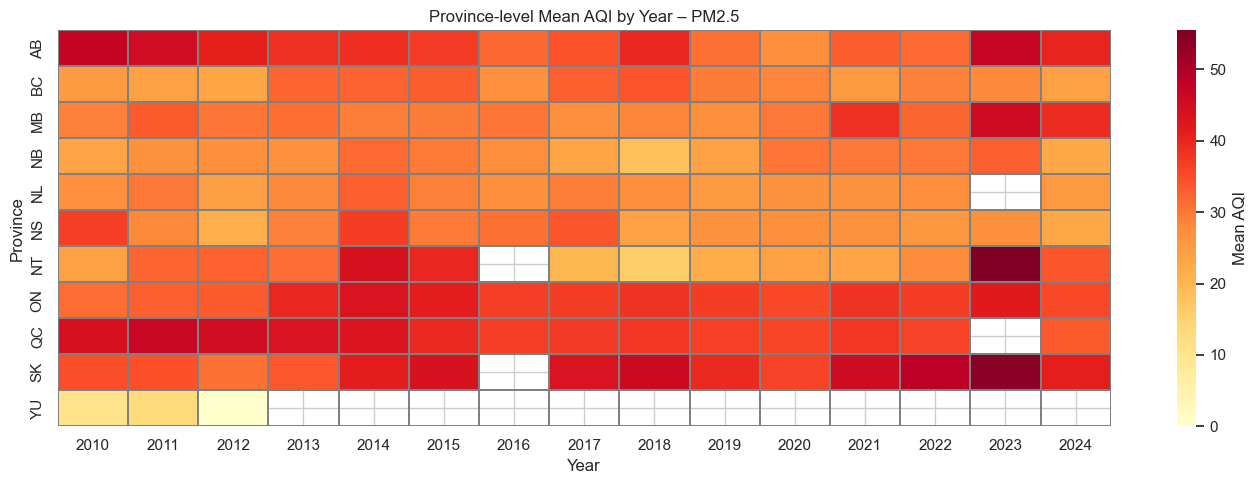

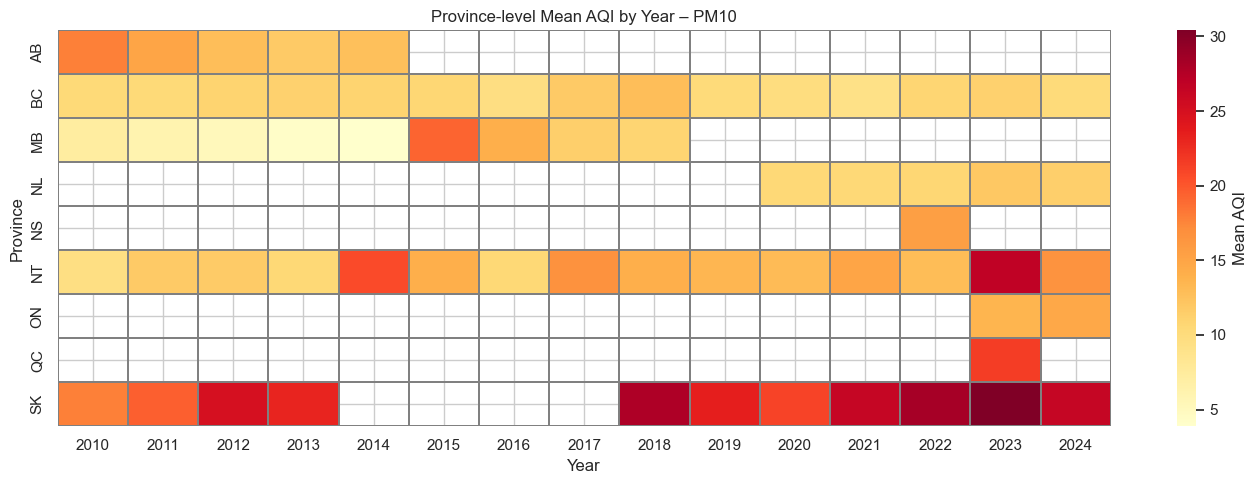

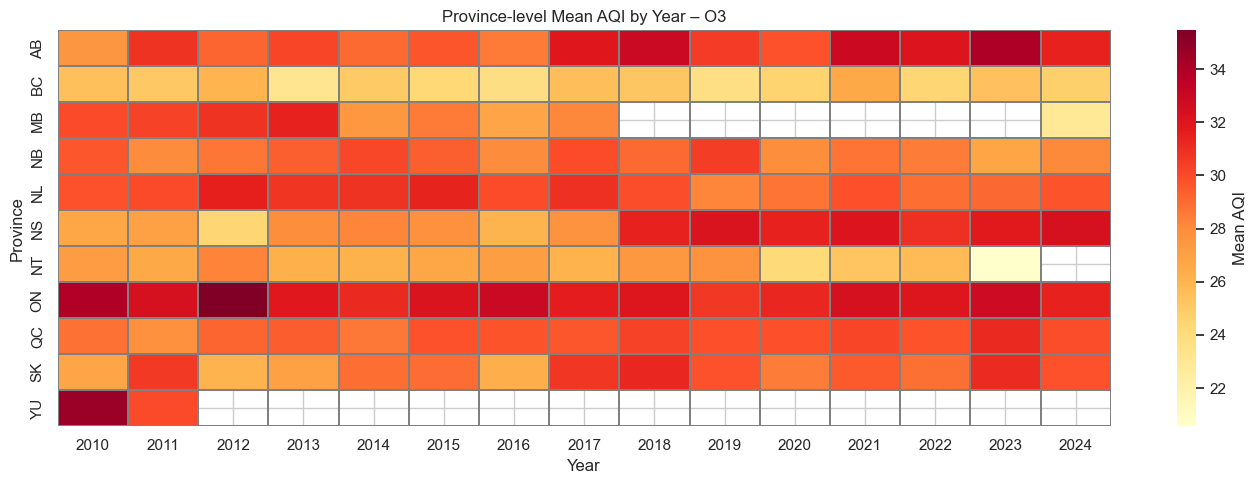

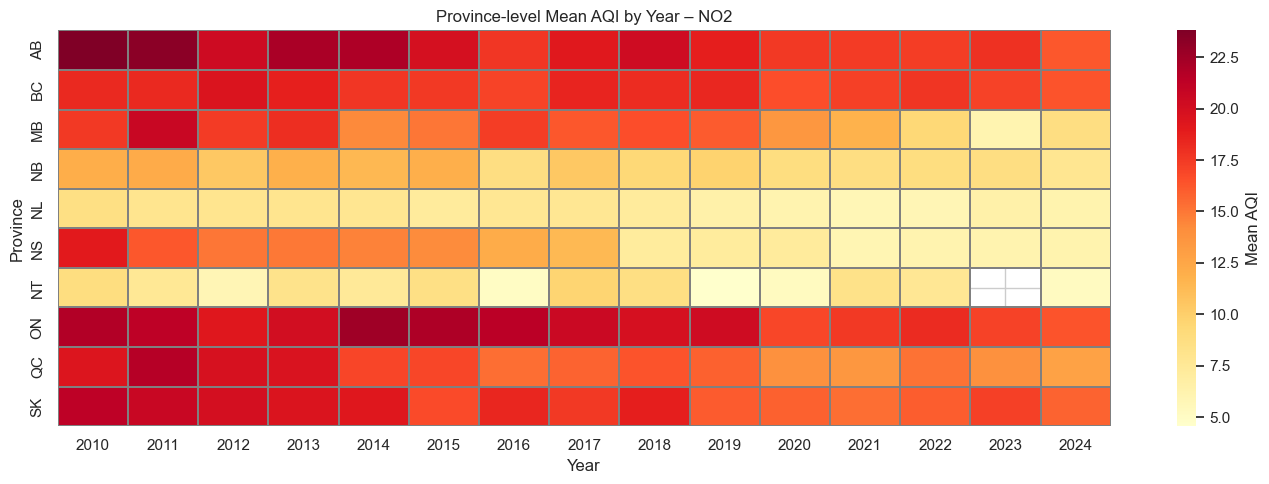

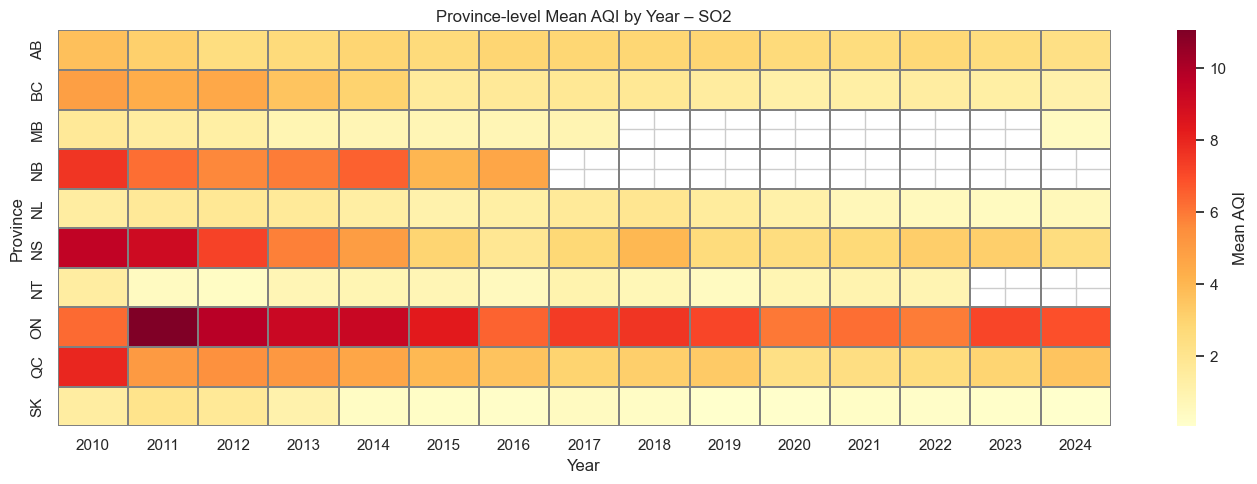

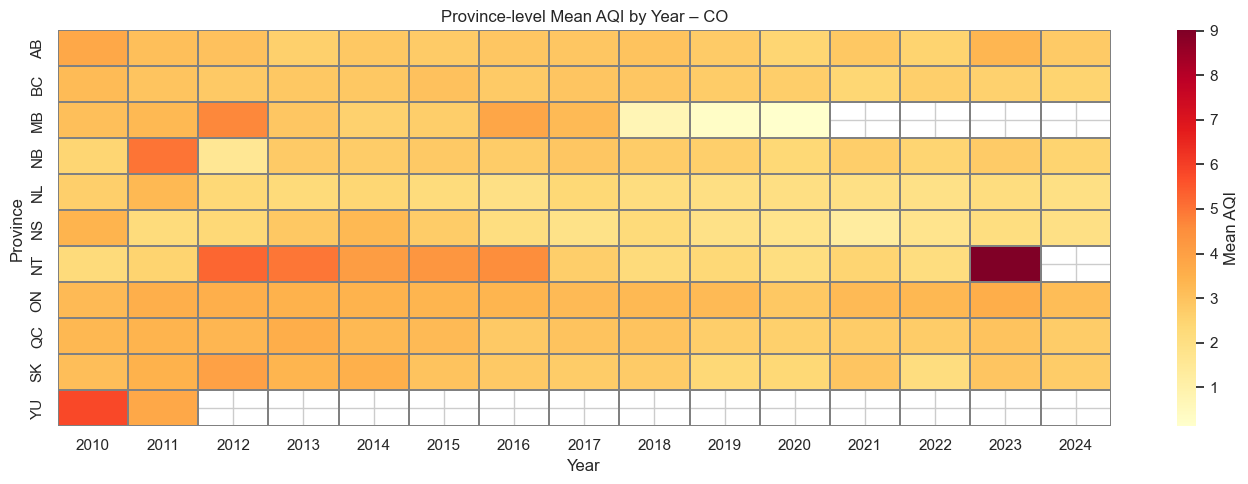

In [56]:
for pollutant, fname in pollutant_files.items():

    # 1️⃣ Read pollutant AQI data
    df = pd.read_csv(DATA_DIR / fname)
    df.rename(columns={"NAPS ID": "NAPS_ID"}, inplace=True)
    df["Date"] = pd.to_datetime(df["Date"])
    df["Year"] = df["Date"].dt.year

    # 2️⃣ Merge with province information
    df = df.merge(
        df_station[["NAPS_ID", "Province"]],
        on="NAPS_ID",
        how="left"
    )

    # 3️⃣ Province-level YEARLY mean AQI
    province_year = (
        df
        .groupby(["Province", "Year"], as_index=False)
        .agg(mean_AQI=("AQI", "mean"))
    )

    # 4️⃣ Pivot for heatmap
    heatmap_df = province_year.pivot(
        index="Province",
        columns="Year",
        values="mean_AQI"
    )

    # 5️⃣ Plot heatmap
    plt.figure(figsize=(14, 5))

    sns.heatmap(
        heatmap_df,
        cmap="YlOrRd",           # excellent AQI-style palette
        linewidths=0.3,
        linecolor="gray",
        cbar_kws={"label": "Mean AQI"}
    )

    plt.title(f"Province-level Mean AQI by Year – {pollutant}")
    plt.xlabel("Year")
    plt.ylabel("Province")
    plt.tight_layout()
    plt.show()

## Small multiples (one province per panel)

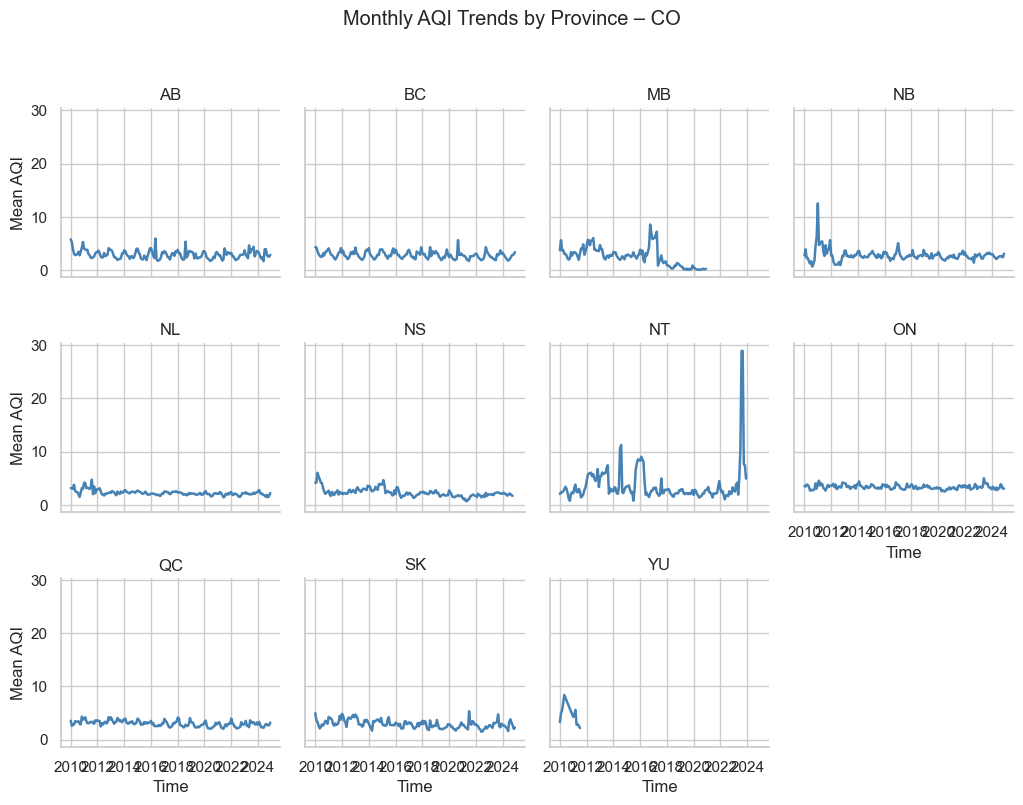

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    province_monthly,
    col="Province",
    col_wrap=4,
    height=2.6,
    sharey=True,
)

g.map_dataframe(
    sns.lineplot,
    x="Month",
    y="mean_AQI",
    linewidth=1.8,
    color="steelblue"
)

g.set_axis_labels("Time", "Mean AQI")
g.set_titles("{col_name}")
plt.suptitle(f"Monthly AQI Trends by Province – {pollutant}", y=1.03)
plt.tight_layout()
plt.show()

## Python function for AQI → color

In [57]:
def aqi_to_color(aqi):
    if pd.isna(aqi):
        return "#d3d3d3"  # light gray for no data
    if aqi <= 50:
        return "#00e400"  # Green
    elif aqi <= 100:
        return "#ffff00"  # Yellow
    elif aqi <= 150:
        return "#ff7e00"  # Orange
    elif aqi <= 200:
        return "#ff0000"  # Red
    elif aqi <= 300:
        return "#8f3f97"  # Purple
    else:
        return "#7e0023"  # Maroon


In [59]:
from matplotlib.colors import ListedColormap, BoundaryNorm

aqi_bounds = [0, 50, 100, 150, 200, 300, 500]
aqi_colors = [
    "#00e400",  # Good
    "#ffff00",  # Moderate
    "#ff7e00",  # USG
    "#ff0000",  # Unhealthy
    "#8f3f97",  # Very Unhealthy
    "#7e0023",  # Hazardous
]

aqi_cmap = ListedColormap(aqi_colors)
aqi_norm = BoundaryNorm(aqi_bounds, aqi_cmap.N)

<Axes: xlabel='Year', ylabel='Province'>

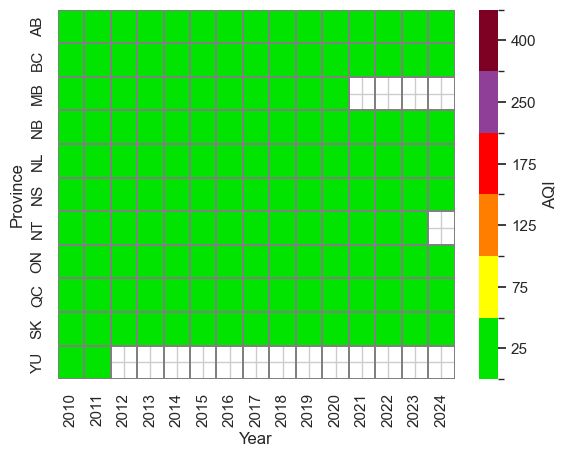

In [60]:
sns.heatmap(
    heatmap_df,
    cmap=aqi_cmap,
    norm=aqi_norm,
    linewidths=0.3,
    linecolor="gray",
    cbar_kws={
        "label": "AQI",
        "ticks": [25, 75, 125, 175, 250, 400]
    }
)

In [62]:
df["Month"] = df["Date"].dt.to_period("M").dt.to_timestamp()

province_month = (
    df
    .groupby(["Province", "Month"], as_index=False)
    .agg(mean_AQI=("AQI", "mean"))
)

heatmap_df = province_month.pivot(
    index="Province",
    columns="Month",
    values="mean_AQI"
)

<Axes: xlabel='Month', ylabel='Province'>

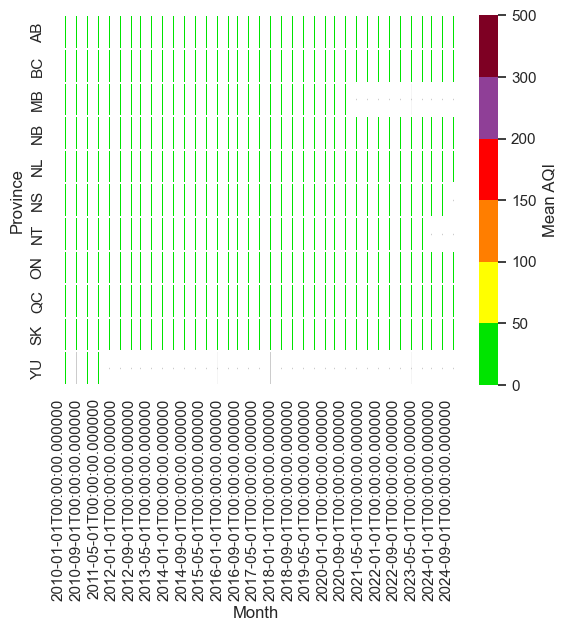

In [63]:
sns.heatmap(
    heatmap_df,
    cmap=aqi_cmap,
    norm=aqi_norm,
    mask=heatmap_df.isna(),
    cbar_kws={"label": "Mean AQI"},
    linewidths=0.2
)

In [64]:
province_year_exceed = (
    df
    .assign(Exceed=df["AQI"] > 50)
    .groupby(["Province", "Year"], as_index=False)
    .agg(pct_exceed=("Exceed", "mean"))
)

heatmap_df = province_year_exceed.pivot(
    index="Province",
    columns="Year",
    values="pct_exceed"
) * 100

<Axes: xlabel='Year', ylabel='Province'>

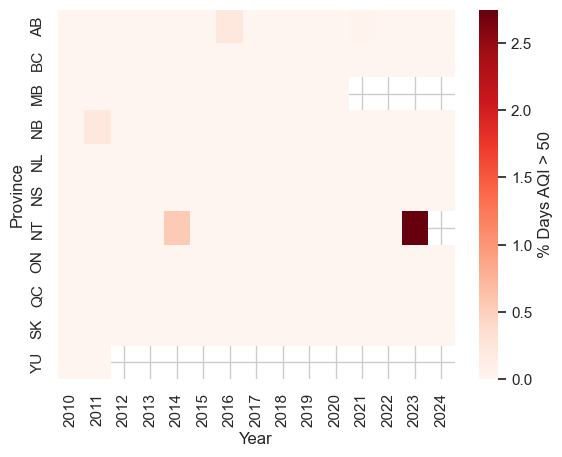

In [65]:
sns.heatmap(
    heatmap_df,
    cmap="Reds",
    cbar_kws={"label": "% Days AQI > 50"}
)

In [66]:
from matplotlib.colors import ListedColormap, BoundaryNorm

aqi_bounds = [0, 50, 100, 150, 200, 300, 500]
aqi_colors = [
    "#00e400",  # Good
    "#ffff00",  # Moderate
    "#ff7e00",  # USG
    "#ff0000",  # Unhealthy
    "#8f3f97",  # Very Unhealthy
    "#7e0023",  # Hazardous
]

aqi_cmap = ListedColormap(aqi_colors)
aqi_norm = BoundaryNorm(aqi_bounds, len(aqi_colors))

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style="white")

DATA_DIR = Path("../../../data/raw/Yashaswi/AQI/AllPollutantsHourly")

YEARS = [2022, 2023, 2024]
MONTH_ORDER = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

In [68]:
for pollutant, fname in pollutant_files.items():

    # ── Read pollutant AQI ─────────────────────────────
    df = pd.read_csv(DATA_DIR / fname)
    df.rename(columns={"NAPS ID": "NAPS_ID"}, inplace=True)
    df["Date"] = pd.to_datetime(df["Date"])

    # ── Merge with province info ───────────────────────
    df = df.merge(
        df_station[["NAPS_ID", "Province"]],
        on="NAPS_ID",
        how="left"
    )

    # ── Extract year and month ─────────────────────────
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["MonthName"] = df["Date"].dt.strftime("%b")

    # ── Monthly mean AQI (NO over-aggregation) ─────────
    monthly = (
        df
        .groupby(["Province", "Year", "Month", "MonthName"], as_index=False)
        .agg(mean_AQI=("AQI", "mean"))
    )

In [69]:
fig, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=(18, 6),
        sharey=True
    )

    for i, year in enumerate(YEARS):
        ax = axes[i]

        sub = monthly[monthly["Year"] == year]

        heatmap_df = (
            sub
            .pivot(index="Province", columns="MonthName", values="mean_AQI")
            .reindex(columns=MONTH_ORDER)
        )

        sns.heatmap(
            heatmap_df,
            ax=ax,
            cmap=aqi_cmap,
            norm=aqi_norm,
            mask=heatmap_df.isna(),
            linewidths=0.4,
            linecolor="gray",
            cbar=(i == 2),  # colorbar only on last plot
            cbar_kws={
                "label": "AQI",
                "ticks": [25, 75, 125, 175, 250, 400]
            }
        )

        ax.set_title(str(year))
        ax.set_xlabel("Month")
        if i == 0:
            ax.set_ylabel("Province")
        else:
            ax.set_ylabel("")

    fig.suptitle(
        f"Province × Month AQI Heatmaps — {pollutant}",
        fontsize=16,
        y=1.05
    )

    plt.tight_layout()
    plt.show()

IndentationError: unexpected indent (733535962.py, line 8)